In [11]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Especificamos el archivo principal del dataset de powerlifting
file_path = "openpowerlifting.csv"

# Cargamos el dataset usando kagglehub
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "dansbecker/powerlifting-database",
  file_path
)

print("Columnas disponibles:")
print(df.columns.tolist())
print("\nPrimeros registros:")
display(df.head())

/tmp/ipykernel_1265/1948549627.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'powerlifting-database' dataset.
Columnas disponibles:
['MeetID', 'Name', 'Sex', 'Equipment', 'Age', 'Division', 'BodyweightKg', 'WeightClassKg', 'Squat4Kg', 'BestSquatKg', 'Bench4Kg', 'BestBenchKg', 'Deadlift4Kg', 'BestDeadliftKg', 'TotalKg', 'Place', 'Wilks']

Primeros registros:


,MeetID,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks
0,0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,NaN,20.41,NaN,70.31,138.35,1,155.05
1,0,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,42.0,Open Senior,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
3,0,Dawn Bogart,F,Raw,42.0,Open Senior,58.51,60,NaN,NaN,NaN,95.25,NaN,NaN,95.25,1,108.29
4,0,Destiny Dula,F,Raw,18.0,Teen 18-19,63.68,67.5,NaN,NaN,NaN,31.75,NaN,90.72,122.47,1,130.47


### 1. Análisis de Características (Features) y Rótulo (Label)

Para este modelo de Powerlifting, nuestro objetivo principal (**rótulo / label**) será predecir el peso total levantado (**`TotalKg`**).

Las características principales (**features**) de entrada que utilizaremos son:
* **`Sex`**: Género del atleta (categórico, requiere codificación binaria).
* **`BodyweightKg`**: Peso corporal del atleta (numérico).
* **`Age`**: Edad del atleta (numérico).

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Selección de columnas relevantes y limpieza rápida
columns_to_keep = ['Sex', 'BodyweightKg', 'Age', 'TotalKg']
data_clean = df[columns_to_keep].dropna()

# 2. Codificación de la variable categórica 'Sex' (M = 1, F = 0)
data_clean['Sex'] = data_clean['Sex'].map({'M': 1, 'F': 0})

# Filtrar posibles valores atípicos o nulos restantes
data_clean = data_clean[(data_clean['Age'] > 0) & (data_clean['BodyweightKg'] > 0) & (data_clean['TotalKg'] > 0)]

# Mostrar el resumen de los datos preparados
print("Resumen estadístico de las variables preparadas:")
display(data_clean.describe())


Resumen estadístico de las variables preparadas:


,Sex,BodyweightKg,Age,TotalKg
count,139195.000000,139195.000000,139195.000000,139195.000000
mean,0.699838,86.913748,31.620317,426.291874
std,0.458330,23.609078,12.922482,206.452553
min,0.000000,15.880000,5.000000,17.000000
25%,0.000000,69.900000,22.000000,260.000000
50%,1.000000,82.850000,28.000000,417.500000
75%,1.000000,100.000000,39.000000,580.000000
max,1.000000,242.400000,95.000000,1363.050000


### 2. Entrenamiento del Modelo de Regresión

In [13]:
# Definir variables independientes (X) y dependiente (y)
X = data_clean[['Sex', 'BodyweightKg', 'Age']]
y = data_clean['TotalKg']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar un modelo Random Forest (con una muestra para agilizar el entrenamiento si el dataset es gigante)
# Usaremos un estimador rápido para obtener resultados ágiles
model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Realizar predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} kg")
print(f"Coeficiente de Determinación (R² Score): {r2:.2f}")

Error Absoluto Medio (MAE): 124.09 kg
Coeficiente de Determinación (R² Score): 0.37


### 3. Visualización de Importancia de Features y Predicciones

/tmp/ipykernel_1265/3299377428.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='viridis')


Text(0.5, 0, 'Importancia Relativa')

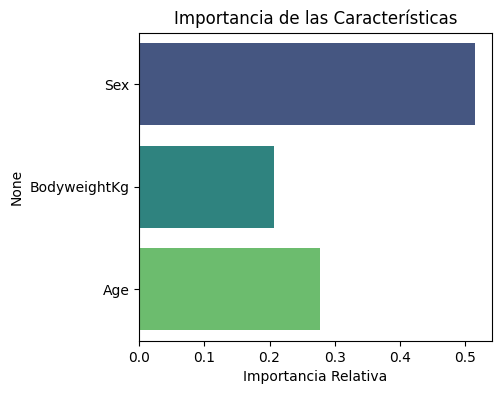

In [15]:
# Graficar la importancia de las variables
importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10, 4))

# Subplot 1: Importancia de características
plt.subplot(1, 2, 1)
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title('Importancia de las Características')
plt.xlabel('Importancia Relativa')

# # Subplot 2: Valores Reales vs Predichos
# plt.subplot(1, 2, 2)
# plt.scatter(y_test, y_pred, alpha=0.1, color='teal')
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
# plt.title('Valores Reales vs Predichos')
# plt.xlabel('Real (Kg)')
# plt.ylabel('Predicho (Kg)')

# plt.tight_layout()
# plt.show()